In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import shap

In [4]:
pd.set_option("display.max_columns", None)
df = pd.read_csv("ea59c58f-e683-4d1d-90d3-baa5f17c3115_Data.csv")
df = df.loc[df["Country Name"] == "United States"]
df = df.drop(['Series Code', 'Country Name', 'Country Code'], axis=1)
df_t = df.set_index('Series Name').T

In [6]:
# if number of patents applied linear to GDP per capita
# select year with records of patents
X = df_t.iloc[20:62, 2:6].astype(float) # GDP per capita
y = df_t.iloc[20:62, 1].to_frame().astype(float) # + df_t.iloc[20:62, 1] # non resident patent

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
print(f"R-squared score: {r2}") # 0.91 for non resident and 0.93 for resident

R-squared score: 0.9761873692693477


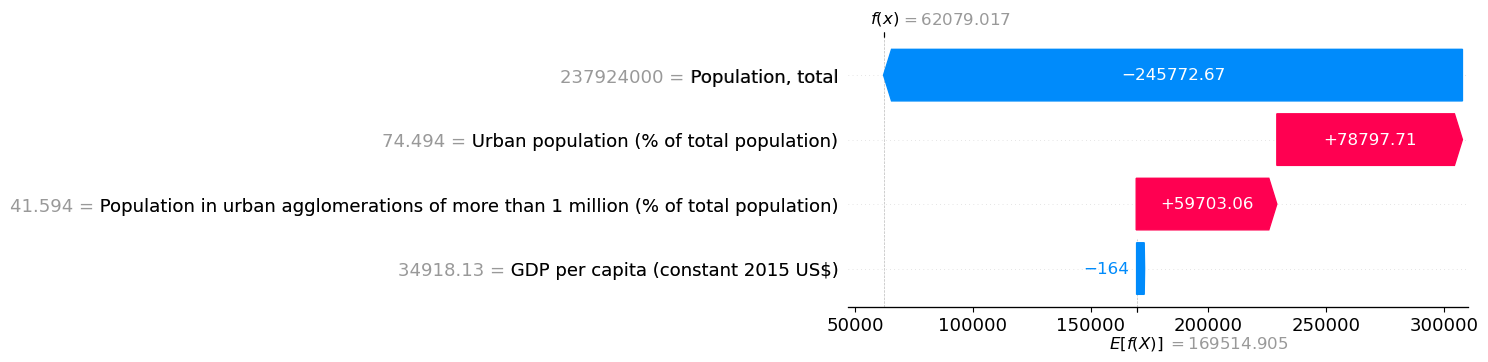

In [7]:
# feature importance
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

shap.plots.waterfall(shap_values[5])